#1. Імпорт всіх необхідних бібліотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import importlib
import src.evaluation
importlib.reload(src.evaluation)
from src.evaluation import evaluate_model, plot_cm
import src.preprocessing
from src.preprocessing import preprocess_news_data

In [ ]:
pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.4f}'.format)
pd.set_option("display.max_colwidth",None)

warnings.filterwarnings('ignore')

#2. Завантаження даних

In [ ]:
train_df = pd.read_csv("data/train.csv.zip")
valid_df = pd.read_csv("data/valid.csv.zip")
test_df = pd.read_csv("data/test.csv.zip")

X_train = train_df["text"]
y_train = train_df["category"]

X_valid = valid_df["text"]
y_valid = valid_df["category"]

X_test = test_df["text"]
y_test = test_df["category"]

#3. Векторизація тексту (TF-IDF)

In [ ]:
start = time.time()

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
tfidf.get_feature_names_out()[:20]

array(['000', '000 people', '10', '10 000', '10 best', '10 million',
       '10 percent', '10 reasons', '10 things', '10 tips', '10 ways',
       '10 year', '10 years', '100', '100 000', '100 days', '100 million',
       '100 percent', '100 years', '101'], dtype=object)

In [ ]:
print("Train:", X_train_tfidf.shape)
print("Validation:", X_valid_tfidf.shape)
print("Test:", X_test_tfidf.shape)

Train: (146335, 10000)
Validation: (31358, 10000)
Test: (31358, 10000)


#4. Побудова baseline-моделі

У якості базової моделі використано поєднання TF-IDF для векторизації текстів та Logistic Regression для їх класифікації.

In [ ]:
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start

formatted_time = time.strftime(
    "%H:%M:%S",
    time.gmtime(training_time)
)

print(f"Час навчання: {formatted_time}")

Час навчання: 00:02:29


# 5. Оцінка baseline-моделі

##5.1 Розрахунок передбачень

In [ ]:
train_accuracy, train_macro_f1, train_weighted_f1, y_train_pred = evaluate_model(
    baseline_model,
    X_train_tfidf,
    y_train
)
valid_accuracy, valid_macro_f1, valid_weighted_f1,  y_valid_pred = evaluate_model(
    baseline_model,
    X_valid_tfidf,
    y_valid
)

##5.2 Порівняння метрик

Основною метрикою оцінювання моделей обрано Macro F1-score, оскільки задача є багатокласовою класифікацією з незбалансованим розподілом класів. Ця метрика дозволяє оцінити якість моделі для всіх категорій незалежно від їх розміру.  

В якості допоміжних метрик обрано:
* Accuracy - показує загальну частку правильних прогнозів.
* Weighted F1-score - вона враховує дисбаланс класів.

Проведемо порівняння метрик:

In [ ]:
results = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "Accuracy": [train_accuracy, valid_accuracy],
    "Macro F1": [train_macro_f1, valid_macro_f1],
    "Weighted F1": [train_weighted_f1, valid_weighted_f1]
})
results

,Dataset,Accuracy,Macro F1,Weighted F1
0,Train,0.6736,0.5551,0.6538
1,Validation,0.5921,0.4345,0.5634


***Висновок:***
* Порівняння значень Accuracy та Macro F1-score на тренувальному та валідаційному наборах свідчить про наявність ознак перенавчання моделі Logistic Regression з використанням TF-IDF. Модель демонструє вищі результати на тренувальному наборі, ніж на валідаційному, що вказує на часткову втрату здатності до узагальнення. Водночас отримані результати на валідаційному наборі залишаються достатньо високими, тому базову модель можна використовувати як орієнтир для порівняння з більш складними підходами.

##5.3 Детальний classification report

Побудуємо детальний звіт для тестовго та валідаційного наборів даних:

In [ ]:
print(classification_report(y_train, y_train_pred))

                precision    recall  f1-score   support

          ARTS       0.63      0.33      0.43      1056
ARTS & CULTURE       0.65      0.24      0.35       937
  BLACK VOICES       0.65      0.44      0.53      3206
      BUSINESS       0.61      0.57      0.59      4192
       COLLEGE       0.60      0.41      0.49       801
        COMEDY       0.69      0.49      0.58      3773
         CRIME       0.65      0.66      0.66      2490
CULTURE & ARTS       0.84      0.34      0.48       751
       DIVORCE       0.86      0.73      0.79      2396
     EDUCATION       0.61      0.37      0.46       710
 ENTERTAINMENT       0.61      0.82      0.70     12150
   ENVIRONMENT       0.81      0.29      0.42      1010
         FIFTY       0.70      0.18      0.28       981
  FOOD & DRINK       0.68      0.82      0.74      4438
     GOOD NEWS       0.70      0.25      0.37       979
         GREEN       0.58      0.48      0.53      1832
HEALTHY LIVING       0.60      0.31      0.41  

In [ ]:
print(classification_report(y_valid, y_valid_pred))

                precision    recall  f1-score   support

          ARTS       0.36      0.18      0.24       227
ARTS & CULTURE       0.37      0.10      0.16       201
  BLACK VOICES       0.50      0.31      0.39       687
      BUSINESS       0.51      0.48      0.49       899
       COLLEGE       0.55      0.31      0.40       171
        COMEDY       0.57      0.41      0.48       809
         CRIME       0.55      0.50      0.53       534
CULTURE & ARTS       0.66      0.20      0.31       161
       DIVORCE       0.83      0.66      0.73       514
     EDUCATION       0.40      0.23      0.29       152
 ENTERTAINMENT       0.55      0.78      0.65      2604
   ENVIRONMENT       0.56      0.16      0.25       216
         FIFTY       0.44      0.11      0.18       210
  FOOD & DRINK       0.61      0.74      0.67       951
     GOOD NEWS       0.50      0.11      0.18       209
         GREEN       0.37      0.31      0.34       393
HEALTHY LIVING       0.40      0.20      0.27  

***Висновки:***
* Базова модель Logistic Regression з TF-IDF ознаками досягла accuracy 0.59 та weighted F1-score 0.56 на validation вибірці. Модель показує найкращі результати для категорій із чіткою тематичною специфікою, таких як POLITICS, SPORTS, STYLE & BEAUTY та TRAVEL.

* Найбільші труднощі класифікації у моделі виникають при класифікації категорій близьких за тематикою, наприклад, ARTS і ARTS & CULTURE, PARENTS і PARENTING.

# 6. Аналіз результатів baseline-моделі

##6.1 Матриця помилок

Побудуємо нормалізовану матрицю помилок навчального та валідаційного наборів даних:

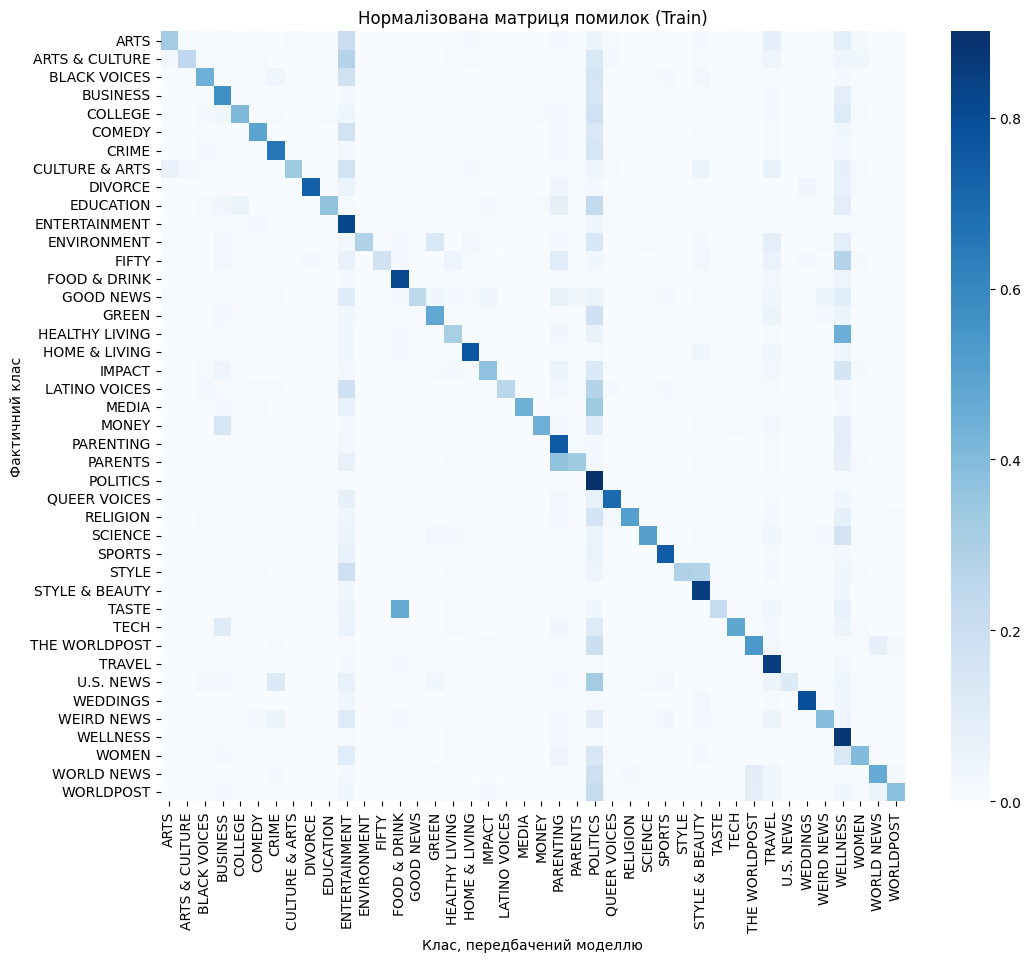

In [ ]:
plot_cm(y_train, y_train_pred, "Train")

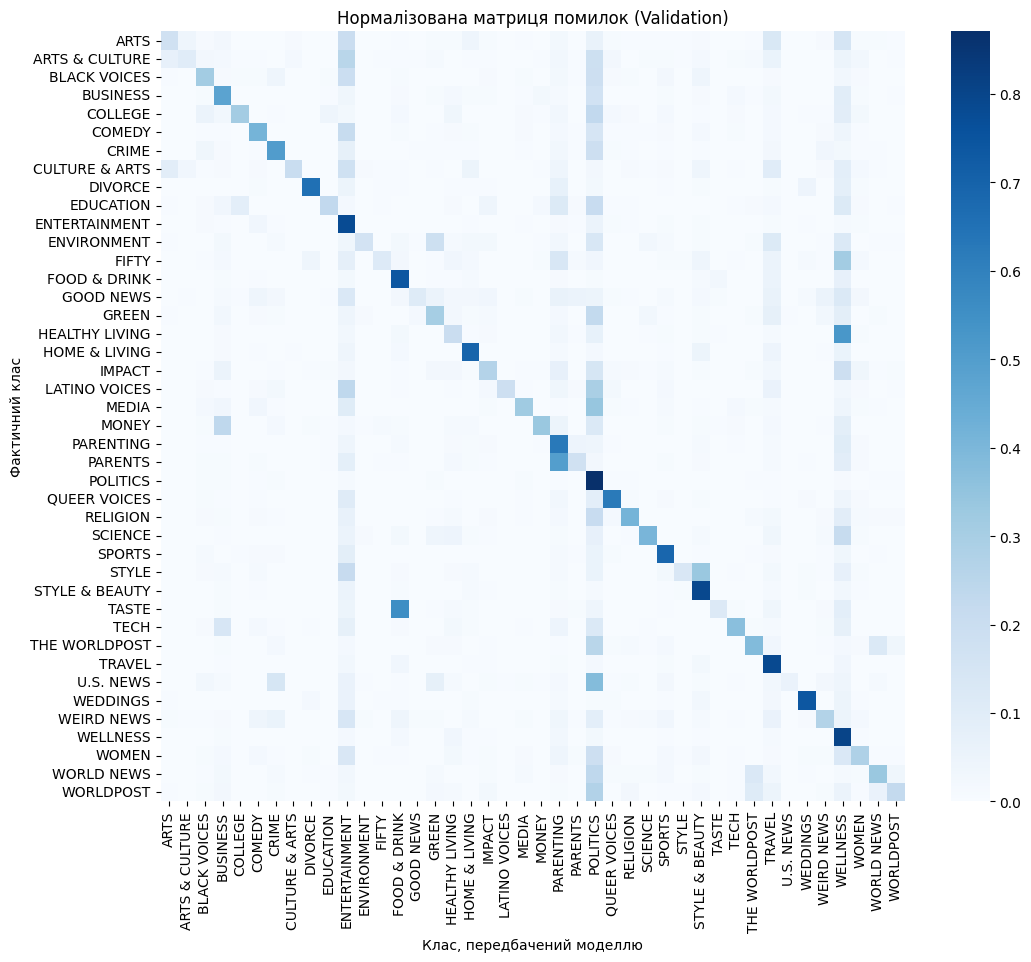

In [ ]:
plot_cm(y_valid, y_valid_pred, "Validation")

***Висновки:***
* Загалом нормалізована матриця помилок для валідаційного набору даних має подібну картину, як і нормалізована матриця помилок для трунвального набору даних.
* Найкраще розпізнаються категорії з чіткою тематичною специфікою, такі як SPORTS, FOOD & DRINK, TRAVEL.
* Основні помилки виникають між близькими категоріями за тематикою, наприклад ARTS і CULTURE & ARTS, PARENTS і PARENTING, POLITICS і U.S. NEWS.

##6.2 Аналіз важливості ознак (Feature importance)

Для інтерпретації роботи моделі проведемо аналіз важливості TF-IDF ознак. Оскільки задача є багатокласовою класифікацією та містить значну кількість категорій, аналіз виконаємо  для декількох обраних класів. Це дозволить визначити слова та словосполучення, які найбільше впливають на прогнозування кожної категорії.

In [ ]:
feature_importance_politics = pd.Series(
    baseline_model.coef_[baseline_model.classes_ == "POLITICS"][0],
    index=tfidf.get_feature_names_out(),
    name="importance_tfidf"
).sort_values(ascending=False)

feature_importance_politics.head(20)

,importance_tfidf
trump,11.9957
gop,7.5028
obama,6.9768
democrats,6.5540
morning email,6.1625
republicans,6.1105
senate,6.0643
congress,5.9289
clinton,5.4952
biden,5.3433


***Висновок:***

* Модель виділяє слова, пов’язані з політикою США та політичними діячами, наприклад senate, obama, trump. Отримані ознаки відповідають тематиці категорії POLITICS, що свідчить про здатність TF-IDF перетворення виділяти інформативні текстові патерни для розділення цього класу.

In [ ]:
feature_importance_business = pd.Series(
    baseline_model.coef_[baseline_model.classes_ == "BUSINESS"][0],
    index=tfidf.get_feature_names_out(),
    name="importance_tfidf"
).sort_values(ascending=False)

feature_importance_business.head(20)

,importance_tfidf
business,6.7593
women business,5.6250
krugman,5.2616
ceo,5.1640
uber,4.8889
workers,4.8040
companies,4.7913
marketing,4.7402
company,4.6151
jobs,4.3187


***Висновок:***

* Модель виділяє слова, пов’язані з економікою, компаніями та фінансовою діяльністю, наприклад tesla, corporate, business. Отримані ознаки відповідають тематиці категорії BUSINESS, що свідчить про здатність TF-IDF перетворення виділяти інформативні текстові патерни для розділення цього класу.

In [ ]:
feature_importance_arts = pd.Series(
    baseline_model.coef_[baseline_model.classes_ == "ARTS"][0],
    index=tfidf.get_feature_names_out(),
    name="importance_tfidf"
).sort_values(ascending=False)

feature_importance_arts.head(20)

,importance_tfidf
art,7.5189
artist,6.1387
nighter,4.9254
opera,4.6604
theatre,4.6437
artists,4.5457
photography,4.5128
theater,4.2830
photographer,4.1111
portraits,3.9592


***Висновок:***

* Модель виділяє слова, пов’язані з різними напрямами мистецтва, зокрема theatre, art, opera. Отримані ознаки відповідають тематиці категорії ARTS, що свідчить про здатність TF-IDF перетворення виділяти інформативні текстові патерни для розділення цього класу.

##6.3 Аналіз помилок моделі

In [ ]:
errors = pd.DataFrame({
    "text": X_valid,
    "true_category": y_valid,
    "predicted_category": y_valid_pred
})

errors = errors[
    errors["true_category"] != errors["predicted_category"]
]

errors.head(20)

,text,true_category,predicted_category
1,U.S. Public Workers Say Organized Labor At 'A Turning Point' Taxpayers have seen drastic cuts in public services after an economic downturn and support for public workers is waning. Union,BUSINESS,POLITICS
2,"Cooking Cous Cous in Fez The sad and suspicious eyes of a decapitated sheep followed us past the fishmonger's stall and back to the kitchen. ""We'll",TRAVEL,FOOD & DRINK
3,"The Best Volunteer Programs Do This If you're wondering why, despite all of your careful planning and grand volunteer and giving activities, your participation numbers are flat, you need to take a look at how you're hooking your employees into your program in the first place.",IMPACT,TRAVEL
9,"Women Leaders in (EU) Foreign Policy: will Mrs Be Better than Lady? On Halloween night, the European Commission -- Europe's ""executive"" -- changed. At the helm of foreign policy, Lady PESC -- as Catherine Ashton was known -- gave way to Mrs PESC, as Federica Mogherini prefers to be called. Two different women leaders, two leadership styles in foreign policy.",WOMEN,WORLDPOST
10,5 Benefits Of Having A Friend With Benefits Who doesn't feel glorious when the sex between you and your partner is fantastic? Some of us believe that friends with benefits,DIVORCE,WELLNESS
17,Kate Hudson And Son Ryder Dance To 'Trap Queen' At The Airport How else do you make waiting for your flight fun?,ENTERTAINMENT,TRAVEL
19,"The Very Best Anti-Aging Skin Strategy Yesterday morning, I woke up ridiculously late, like 10 am, feeling like a prizefighter who had taken in the full 15 rounds. It felt great to sleep in -- 'this must be what the kids feel like -- late nights -- deep long sleeps -- delish.' Splashing refreshing cold water on my face -- I looked up and I caught a glimpse of -- someone else?",FIFTY,WELLNESS
20,Why Does Your Dog Cock Its Head? Is Head-Tilting a Sign of Intelligence? Or Something Else? Or is she? What’s really happening when your dog tilts her head,ENVIRONMENT,WEIRD NEWS
24,"Medicine For Another Day A “new era” in medicine does not come along very often. We had one, perhaps, in 1854 when John Snow effectively invented",HEALTHY LIVING,WELLNESS
26,"This Law Lets Abused Animals Get Their Own Advocates In Court Connecticut is the first state to pass this kind of legislation, a professor says.",CRIME,POLITICS


In [ ]:
print(f"Кількість помилок: {len(errors)}")
print(f"Частка помилок: {len(errors) / len(y_valid):.2%}")

Кількість помилок: 12790
Частка помилок: 40.79%


In [ ]:
errors_pairs = (
    errors
    .groupby(["true_category", "predicted_category"])
    .size()
    .sort_values(ascending=False)
)

errors_pairs.head(15)

,,0
true_category,predicted_category,
HEALTHY LIVING,WELLNESS,529
PARENTS,PARENTING,291
TASTE,FOOD & DRINK,175
COMEDY,ENTERTAINMENT,171
BUSINESS,POLITICS,152
MEDIA,POLITICS,151
THE WORLDPOST,POLITICS,139
ENTERTAINMENT,POLITICS,138
PARENTING,WELLNESS,135


***Висновки:***

* Аналіз помилок моделі показує, що більшість неправильних прогнозів виникає між тематично близькими категоріями.